# Chapter 12: A minimal implementation of DALL-E





Open in Colab:    
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/drive/1uhA9Q66FX1mhXzUd3DBtaqI1CEKrsaWd?usp=sharing)



This chapter covers:

* How DALL-E is trained to generate images from text descriptions
* How a pretrained BART encoder transforms a text prompt into dense embeddings
* How an autoregressive BART decoder uses those embeddings to predict a sequence of image tokens
* How a VQGAN decoder converts image tokens into visual patches and reconstructs them into a complete high-resolution image

OpenAI’s DALL-E is one of the earliest and most influential text-to-image generators. It is a large-scale transformer that can generate high-resolution images from natual language prompts. DALL-E stands at the intersection of two technologies in modern AI: powerful autoregressive language models and vector-quantized representations of visual information. Yet, for many learners, practitioners, and researchers, the full DALL-E model remains out of reach due to its proprietary nature.

To foster deeper understanding and democratize access, the open-source community has stepped up, replicating DALL·E’s core ideas with public tools and datasets. Notably, the DALL-E Mini project and its streamlined PyTorch reimplementation, min-DALL-E, have made it possible for anyone to explore the mechanics of transformer-based text-to-image generation and even build their own models from scratch.
In this chapter, you’ll learn to build a transformer-based text-to-image generator from scratch, not treating it as a black box, but instead working through every stage of the process. You’ll learn how a Bidirectional and Autoregressive Transformer (BART) encoder transforms a text prompt into rich vector embeddings, how the BART decoder translates those embeddings into a sequence of image tokens, and finally, how a vector-quantized generative adversarial network (VQGAN) decoder reconstructs those tokens into a complete high-resolution image.

To make the process tangible, we’ll use a simple, vivid prompt, “panda with top hat reading a book,” and go through each stage of the pipeline. Along the way, you’ll see not only the final result, but also the intermediate outputs: what the model produces after generating just 32, 64, or 128 of the eventual 256 image tokens. This incremental visualization will give you an intuitive grasp of how the image gradually takes shape as the model “paints” patch by patch.

**Less grammatically formal prompts**

*You may have noticed that the prompt "panda with top hat reading a book" is grammatically informal. Image generation models, such as DALL-E or Stable Diffusion, prioritize the semantics and content of prompts rather than strict grammatical correctness. In practice, shorter and less grammatically formal prompts can often lead to clearer and more visually appealing results, because the model easily identifies the main subjects and actions.*

Figure 12.1 illustrates how this chapter fits into your journey so far. Throughout the book, you’ve built up the knowledge and tools needed for text-to-image generation from scratch. Now, in step 8, you’ll build upon the VQGAN model you learned in the previous chapter to replicate a transformer-based generator similar to DALL-E. 
 
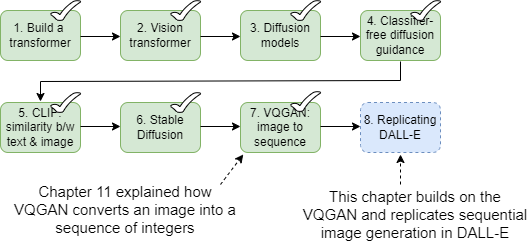

By the end of the chapter, you’ll not only understand the architecture and training procedure of DALL-E-like models, but you’ll also gain hands-on experience generating images from text prompts using the min-DALL-E implementation. Along the way, you’ll deepen your understanding of key generative modeling concepts such as vector quantization, autoregressive decoding, temperature scaling, and top-K sampling.


# 1. How Does DALL-E Work?
# 2. Tokenize and Encode the Text Prompt

## 2.1	Tokenize the text prompt

First, clone the GitHub repository by Brett Kuprel, https://github.com/kuprel/min-dalle, to your computer:

In [1]:
!git clone https://github.com/kuprel/min-dalle

In [2]:
import os

folder="files/DALLE"
if not os.path.exists(folder):    #A
    os.makedirs(folder)
#A If the folder /files/DALLE/ is not on your computer, create the folder

In [3]:
import requests

url='https://huggingface.co/kuprel/min-dalle/resolve/main/'
vocab_path=folder+"/vocab.json"
merges_path=folder+"/merges.txt"
  
if not (os.path.exists(vocab_path)
    and os.path.exists(merges_path)):    #A
    print("downloading tokenizer parameters")
    
    vocab = requests.get(url + 'vocab.json')
    merges = requests.get(url + 'merges.txt')
    with open(vocab_path, 'wb') as f: 
        f.write(vocab.content)
    with open(merges_path, 'wb') as f:    #B 
        f.write(merges.content)   
else:    #C
    print("tokenizer parameters have already been downloaded")
#A If either vocab.json or merges.txt is not on your computer, start downloading   
#B Download the two files and save them on your computer
#C Skip if the two files have already been downloaded

tokenizer parameters have already been downloaded


In [4]:
import sys
sys.path.append("min-dalle")    #A 

import json
from min_dalle.text_tokenizer import TextTokenizer    #B   

print("intializing TextTokenizer")
with open(vocab_path, 'r', encoding='utf8') as f:
    vocab = json.load(f)
with open(merges_path, 'r', encoding='utf8') as f:
    merges = f.read().split("\n")[1:-1]    #C
tokenizer = TextTokenizer(vocab, merges)    #D
#A Add the /min-dalle/ folder to Python’s search path
#B Import the TextTokenizer() class from the min-DALL-E GitHub repository
#C Load the tokenizer files
#D Initializing the tokenizer

intializing TextTokenizer


In [5]:
print({k:v for k,v in vocab.items() if v<10})

{'<s>': 0, '<pad>': 1, '</s>': 2, '<unk>': 3, '<mask>': 4, '"': 5, '$': 6, '%': 7, '&': 8, "'": 9}


In [6]:
text = "panda with top hat reading a book"
token_ids = tokenizer.tokenize(text)    #A
print("Token IDs:", token_ids)

idx2token = {v: k for k, v in vocab.items()}    #B

raw_tokens = [idx2token.get(i, "<unk>") for i in token_ids]
print("Raw Tokens:", raw_tokens)
#A Tokenize text to get token IDs
#B Reverse the vocab dictionary to map IDs to tokens
#C Map token IDs to raw tokens

Token IDs: [0, 8418, 208, 479, 2583, 4132, 58, 407, 2]
Raw Tokens: ['<s>', 'Ġpanda', 'Ġwith', 'Ġtop', 'Ġhat', 'Ġreading', 'Ġa', 'Ġbook', '</s>']


In [7]:
# answer to Exercise 12.1
text2 = "an underwater fantasy city" 
token_ids2 = tokenizer.tokenize(text2)    
print("Token IDs:", token_ids2)
raw_tokens2 = [idx2token.get(i, "<unk>") for i in token_ids2]
print("Raw Tokens:", raw_tokens2)

Token IDs: [0, 101, 10892, 3091, 645, 2]
Raw Tokens: ['<s>', 'Ġan', 'Ġunderwater', 'Ġfantasy', 'Ġcity', '</s>']


In [8]:
import numpy, torch

device="cuda" if torch.cuda.is_available() else "cpu"

text_tokens = numpy.ones((2, 64), dtype=numpy.int32)    #A
text_tokens[0, :2] = [token_ids[0], token_ids[-1]]    #B
text_tokens[1, :len(token_ids)] = token_ids    #C
text_tokens = torch.tensor(text_tokens, 
    dtype=torch.long, device=device)    #D
print(text_tokens)
#A Initialize a NumPy array filled with the <pad> token (index 1)
#B Create the unconditional prompt, with just two tokens <s> and </s>
#C Create the padded conditional prompt
#D Convert the input to a PyTorch long tensor

tensor([[   0,    2,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
            1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
            1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
            1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
            1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
            1,    1,    1,    1],
        [   0, 8418,  208,  479, 2583, 4132,   58,  407,    2,    1,    1,    1,
            1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
            1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
            1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
            1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
            1,    1,    1,    1]], device='cuda:0')


In [9]:
# answer to Exercise 12.2
text_tokens2 = numpy.ones((2, 64), dtype=numpy.int32)    
text_tokens2[0, :2] = [token_ids2[0], token_ids2[-1]]    
text_tokens2[1, :len(token_ids2)] = token_ids2    
text_tokens2 = torch.tensor(text_tokens2, 
    dtype=torch.long, device=device)    
print(text_tokens2)

tensor([[    0,     2,     1,     1,     1,     1,     1,     1,     1,     1,
             1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
             1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
             1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
             1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
             1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
             1,     1,     1,     1],
        [    0,   101, 10892,  3091,   645,     2,     1,     1,     1,     1,
             1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
             1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
             1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
             1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
             1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
             1

## 2.2	Encode the text prompt

In [10]:
encoder_path=folder+"/encoder.pt"
  
if not os.path.exists(encoder_path):    #A
    print("downloading encoder parameters")
    ws = requests.get(url + 'encoder.pt')
    with open(encoder_path, 'wb') as f: 
        f.write(ws.content)
else:    #B
    print("encoder parameters have already been downloaded")
#A If the weights are not available locally, download them from Hugging Face
#B Otherwise, skip downloading

encoder parameters have already been downloaded


In [11]:
from min_dalle.models import DalleBartEncoder

torch.manual_seed(42)    #A 
dtype = "float16" 
print("initializing DalleBartEncoder")
encoder = DalleBartEncoder(    #B
    attention_head_count = 32,
    embed_count = 2048,    #C
    glu_embed_count = 4096,
    text_token_count = 64,    #D
    text_vocab_count = 50272,
    layer_count = 24,
    device=device
).to(getattr(torch, dtype)).eval()
params = torch.load(encoder_path)
encoder.load_state_dict(params, strict=False)    #E
del params
encoder = encoder.to(device)
#A Fix the random state so results are reproducible
#B Instantiate the DalleBartEncoder() class to create the BART encoder
#C Text embeddings have a dimension of 2048
#D Text prompts have 64 tokens
#E Load the pretrained weights

initializing DalleBartEncoder


In [12]:
with torch.amp.autocast("cuda", dtype=getattr(torch, dtype)):
    encoder_state = encoder.forward(text_tokens)    
torch.cuda.empty_cache()
print("Shape of the text embeddings:", encoder_state.shape)

Shape of the text embeddings: torch.Size([2, 64, 2048])


In [13]:
# answer to exercise 12.3
with torch.amp.autocast("cuda", dtype=getattr(torch, dtype)):
    encoder_state2 = encoder.forward(text_tokens2)    
torch.cuda.empty_cache()
print("Shape of the text embeddings:", encoder_state2.shape)

Shape of the text embeddings: torch.Size([2, 64, 2048])


# 3. Iterative Prediction of Image Tokens 

## 3.1 Load the Pretrained BART Decoder

In [14]:
decoder_path=folder+"/decoder.pt"
  
if not os.path.exists(decoder_path):    #A
    print("downloading decoder parameters")
    weights = requests.get(url + 'decoder.pt')
    with open(decoder_path, 'wb') as f: 
        f.write(weights.content)
else:
    print("decoder parameters have already been downloaded")
#A Download the pretrained BART decoder weights if they are not saved locally

decoder parameters have already been downloaded


In [15]:
from min_dalle.models import DalleBartDecoder
 
print("initializing DalleBartDecoder")
decoder = DalleBartDecoder(    #A
    image_vocab_count = 16415,
    attention_head_count = 32,
    embed_count = 2048,
    glu_embed_count = 4096,
    layer_count = 24,
    device=device
).to(getattr(torch, dtype)).eval()
params = torch.load(decoder_path)    #B
decoder.load_state_dict(params, strict=False)
del params
decoder = decoder.to(device)
#A Create a BART decoder
#B Load the trained weights

initializing DalleBartDecoder


## 3.2 Predict Image Tokens Using the BART Decoder

In [16]:
attention_mask=text_tokens.not_equal(1)[:, None, None, :]    #A
attention_state=torch.zeros(size=(24,4,256,2048),    #B
    device=device)
image_tokens=torch.full((1, 256 + 1),    #C 
    2 ** 14 - 1,dtype=torch.long,device=device)
#A Create an attention mask
#B Create an attention_state cache
#C Create a sequence of 257 image tokens, filled with a special placeholder token

In [17]:
# answer to exercise 12.4
attention_mask2=text_tokens2.not_equal(1)[:, None, None, :]    
attention_state2=torch.zeros(size=(24,4,256,2048),    
    device=device)
image_tokens2=torch.full((1, 256 + 1),    
    2 ** 14 - 1,dtype=torch.long,device=device)

In [18]:
token_indices=torch.arange(256,device=device)
temperature=0.5    #A
top_k=128    #B
supercondition_factor=4    #C
settings = torch.tensor(
    [temperature, top_k, supercondition_factor], 
    dtype=torch.float32,device=device)
#A Set the temperature parameter to 0.5
#B Set the top-K sampling parameter to 128
#C Set the supercondition factor to 4

In [19]:
from copy import deepcopy

imgtokens=[]    #A
for i in range(256):    #B
    torch.cuda.empty_cache()                
    with torch.amp.autocast("cuda",dtype=getattr(torch, dtype)):
        image_tokens[:, i + 1], attention_state = decoder.sample_tokens(    #C
            settings=settings,
            attention_mask=attention_mask,
            encoder_state=encoder_state,
            attention_state=attention_state,
            prev_tokens=image_tokens[:, [i]],
            token_index=token_indices[[i]])
        imgtokens.append(deepcopy(image_tokens))
#A Create a list imgtokens to store intermediate steps
#B Iterate 256 steps
#C Predict the next token using previous tokens and the text embeddings

In [20]:
# answer to exercise 12.5
imgtokens2=[]    
for i in range(256):    
    torch.cuda.empty_cache()                
    with torch.amp.autocast("cuda",dtype=getattr(torch, dtype)):
        image_tokens2[:, i + 1], attention_state2 = decoder.sample_tokens(    
            settings=settings,
            attention_mask=attention_mask2,
            encoder_state=encoder_state2,
            attention_state=attention_state2,
            prev_tokens=image_tokens2[:, [i]],
            token_index=token_indices[[i]])
        imgtokens2.append(deepcopy(image_tokens2))

# 4. Converting Image Tokens to High-Resolution Images

## 4.1 Load the Pretrained VQGAN Detokenizer


In [21]:
detokenizer_path=folder+"/detoker.pt"
if not os.path.exists(detokenizer_path):    #A
    print("downloading detokenizer parameters")
    ws = requests.get(url + 'detoker.pt')
    with open(detokenizer_path, 'wb') as f: 
        f.write(ws.content)
else:
    print("detokenizer parameters have already been downloaded")
#A Download the pretrained weights for the VQGAN detokenizer 

detokenizer parameters have already been downloaded


In [22]:
from min_dalle.models import VQGanDetokenizer

print("initializing VQGanDetokenizer")
detokenizer = VQGanDetokenizer().eval()    #A
params = torch.load(detokenizer_path)
detokenizer.load_state_dict(params)    #B
del params
detokenizer = detokenizer.to(device)
#A Initialize the VQGAN detokenizer and set it to evaluation mode
#B Load the pretrained weights

initializing VQGanDetokenizer


## 4.2 Visualize the Intermediate and Fianl High-Resolution Outputs

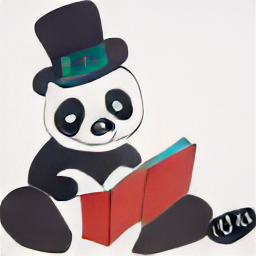

In [23]:
from PIL import Image

torch.cuda.empty_cache()
image = detokenizer.forward(True,
        image_tokens[:, 1:])    #A          
image = image.to(torch.uint8).to('cpu').numpy()    #B
image = Image.fromarray(image)    #C
image.save("files/minDALLE.png")
image
#A Decode image tokens to an image tensor (skip the BOS token)
#B Convert the image tensor to NumPy arrays
#C Convert NumPy arrays to an actual image using the PIL library

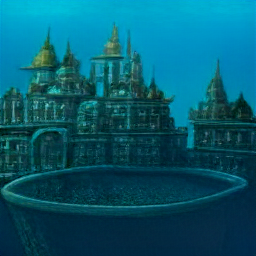

In [24]:
# answer to exercise 12.6
torch.cuda.empty_cache()
image2 = detokenizer.forward(True,
        image_tokens2[:, 1:])              
image2 = image2.to(torch.uint8).to('cpu').numpy()    
image2 = Image.fromarray(image2)    
image2

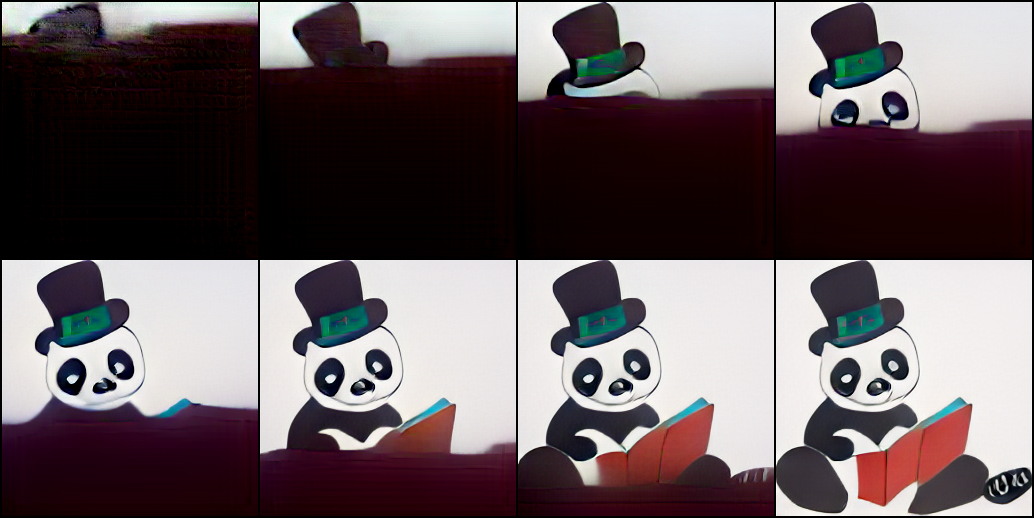

In [25]:
from torchvision.utils import make_grid
from torchvision.transforms import ToPILImage

imgs=[]
for i in range(8):
    torch.cuda.empty_cache()
    images = detokenizer.forward(True, 
      imgtokens[32*(i+1)-1][:, 1:])    #A         
    imgs.append(images.permute(2,0,1).to(torch.uint8))
grid=make_grid(imgs,nrow=4)    #B
img=ToPILImage()(grid)
img.save("files/minDALLEsteps.png")
img
#A Select images at steps 32, 64, 96, 128, 160, 192, 224, and 256.
#B Place the 8 images in a 2x4 grid

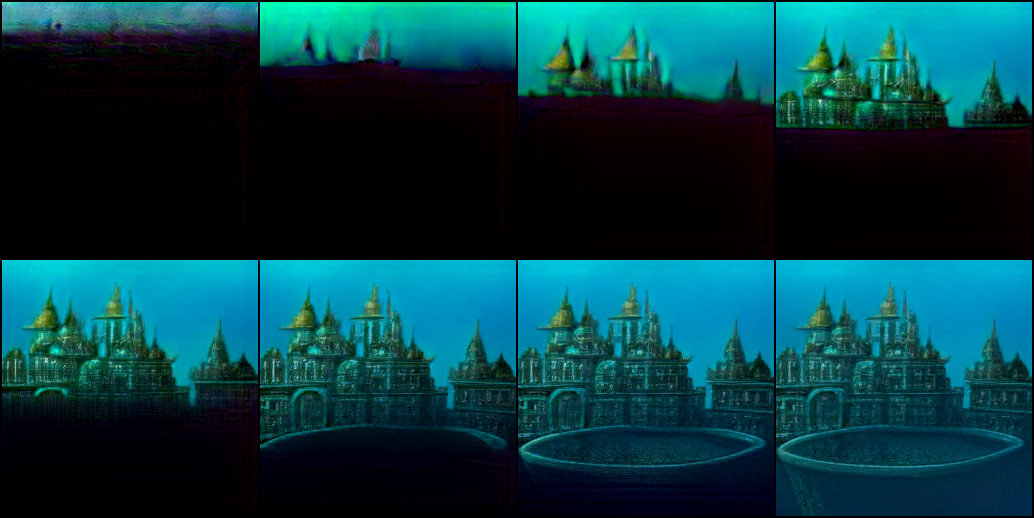

In [26]:
# Answer to exercise 12.7
imgs2=[]
for i in range(8):
    torch.cuda.empty_cache()
    images = detokenizer.forward(True, 
      imgtokens2[32*(i+1)-1][:, 1:])    #A         
    imgs2.append(images.permute(2,0,1).to(torch.uint8))
grid2=make_grid(imgs2,nrow=4)    
img2=ToPILImage()(grid2)
img2

In [27]:
vids=[]    #A
for i in range(len(imgtokens)):
    torch.cuda.empty_cache()
    images = detokenizer.forward(True, 
      imgtokens[i][:, 1:])    #B         
    image = images.to(torch.uint8).to('cpu').numpy()
    vids.append(Image.fromarray(image))    

import imageio
imageio.mimsave("files/minDALLE.gif",    #C
        vids,fps=30)
#A Create a list vids to store all intermediate images
#B Generate an image in each of the 256 intermediate steps
#C Use the imageio library to create an animation

If you go to the /files/ folder on your computer, you'll see the animation minDALLE.gif, or you can view it here https://drive.google.com/file/d/1GNKX0O_qprwg28E2O8U0xq7kzUMLoE6F/view.

In [28]:
# answer to exercise 12.8
vids2=[]    
for i in range(len(imgtokens2)):
    torch.cuda.empty_cache()
    images = detokenizer.forward(True, 
      imgtokens2[i][:, 1:])            
    image = images.to(torch.uint8).to('cpu').numpy()
    vids2.append(Image.fromarray(image))    

imageio.mimsave("files/minDALLE2.gif",    #C
        vids2,fps=30)